In [ ]:
### pip install pystan
### conda install -c conda-forge fbprophet
!pip install prophet
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df=pd.read_csv('/content/AEP_hourly.csv')

In [ ]:
df.shape


(121273, 2)

In [ ]:
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [ ]:
df.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


<Axes: >

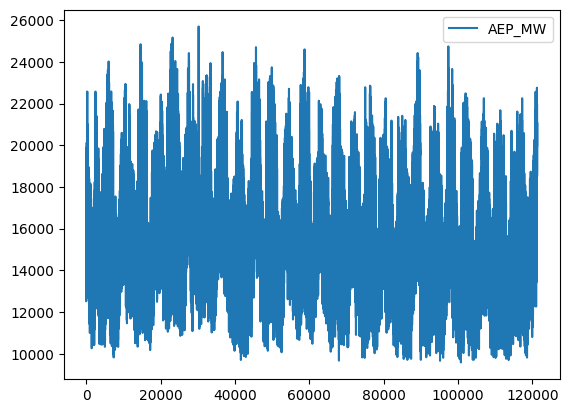

In [ ]:
df.plot()

In [ ]:
df.columns = ['ds','y']
df.head()

,ds,y
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [ ]:
df.drop(144,axis=0,inplace=True)

In [ ]:
df.tail()

,ds,y
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [ ]:
df['ds'] = pd.to_datetime(df['ds'])

In [ ]:
df.head()

,ds,y
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [ ]:
df.tail()

,ds,y
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [ ]:
dir(Prophet)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 

In [ ]:
# Initialize the Model
model=Prophet()

In [ ]:
df.columns

Index(['ds', 'y'], dtype='object')

In [ ]:
df.dropna(axis=0,inplace=True)
df.head()

,ds,y
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [ ]:
model.fit(df)

In [ ]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'daily',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [ ]:
df.tail()

,ds,y
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [ ]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)

In [ ]:
future_dates.tail()

,ds
121628,2019-07-30
121629,2019-07-31
121630,2019-08-01
121631,2019-08-02
121632,2019-08-03


In [ ]:
prediction=model.predict(future_dates)

In [ ]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2004-10-01 01:00:00,15309.262921,10921.086699,14739.053462,15309.262921,15309.262921,-2502.120846,-2502.120846,-2502.120846,-1518.573305,...,480.615943,480.615943,480.615943,-1464.163483,-1464.163483,-1464.163483,0.0,0.0,0.0,12807.142075
1,2004-10-01 02:00:00,15309.352857,10281.608511,14156.320796,15309.352857,15309.352857,-3086.453828,-3086.453828,-3086.453828,-2091.125860,...,470.454172,470.454172,470.454172,-1465.782139,-1465.782139,-1465.782139,0.0,0.0,0.0,12222.899029
2,2004-10-01 03:00:00,15309.442794,9901.112830,13829.890107,15309.442794,15309.442794,-3426.596810,-3426.596810,-3426.596810,-2418.583211,...,459.387424,459.387424,459.387424,-1467.401022,-1467.401022,-1467.401022,0.0,0.0,0.0,11882.845984
3,2004-10-01 04:00:00,15309.532731,9830.327351,13760.948419,15309.532731,15309.532731,-3474.790033,-3474.790033,-3474.790033,-2453.077394,...,447.307465,447.307465,447.307465,-1469.020104,-1469.020104,-1469.020104,0.0,0.0,0.0,11834.742698
4,2004-10-01 05:00:00,15309.622668,10174.212813,14135.352058,15309.622668,15309.622668,-3198.642033,-3198.642033,-3198.642033,-2162.101829,...,434.099150,434.099150,434.099150,-1470.639354,-1470.639354,-1470.639354,0.0,0.0,0.0,12110.980634


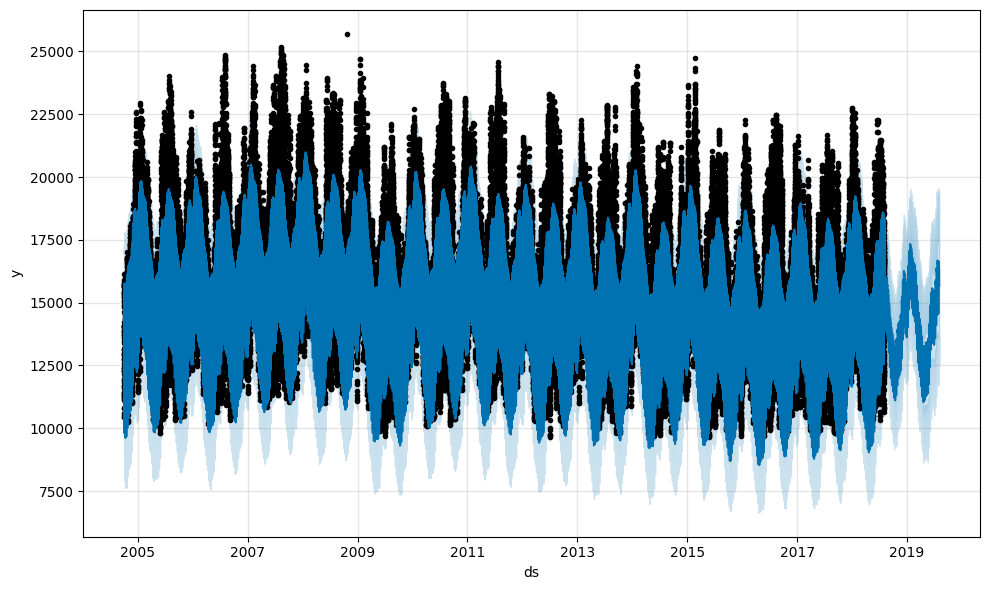

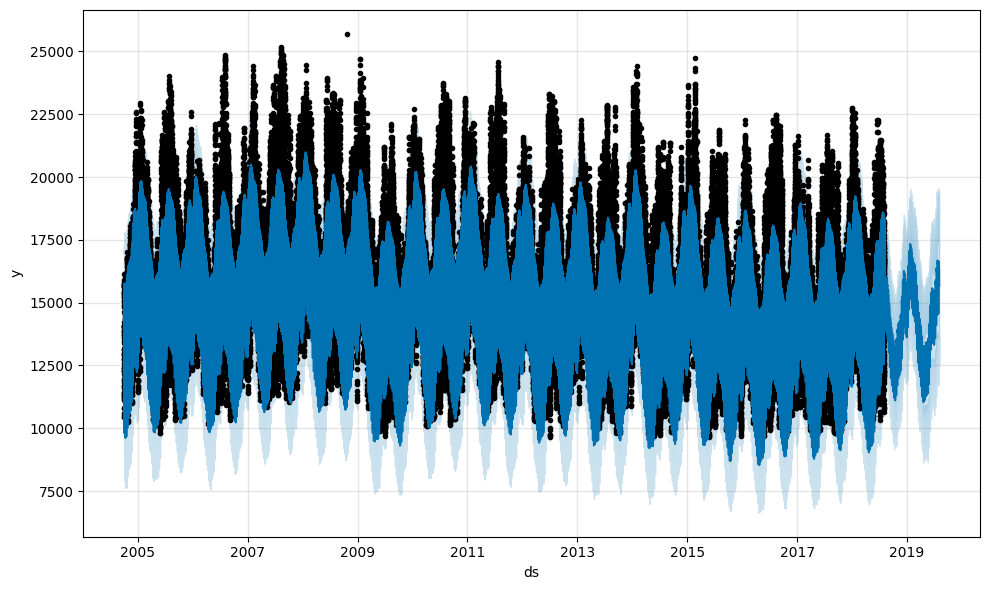

In [ ]:
### plot the predicted projection
model.plot(prediction)

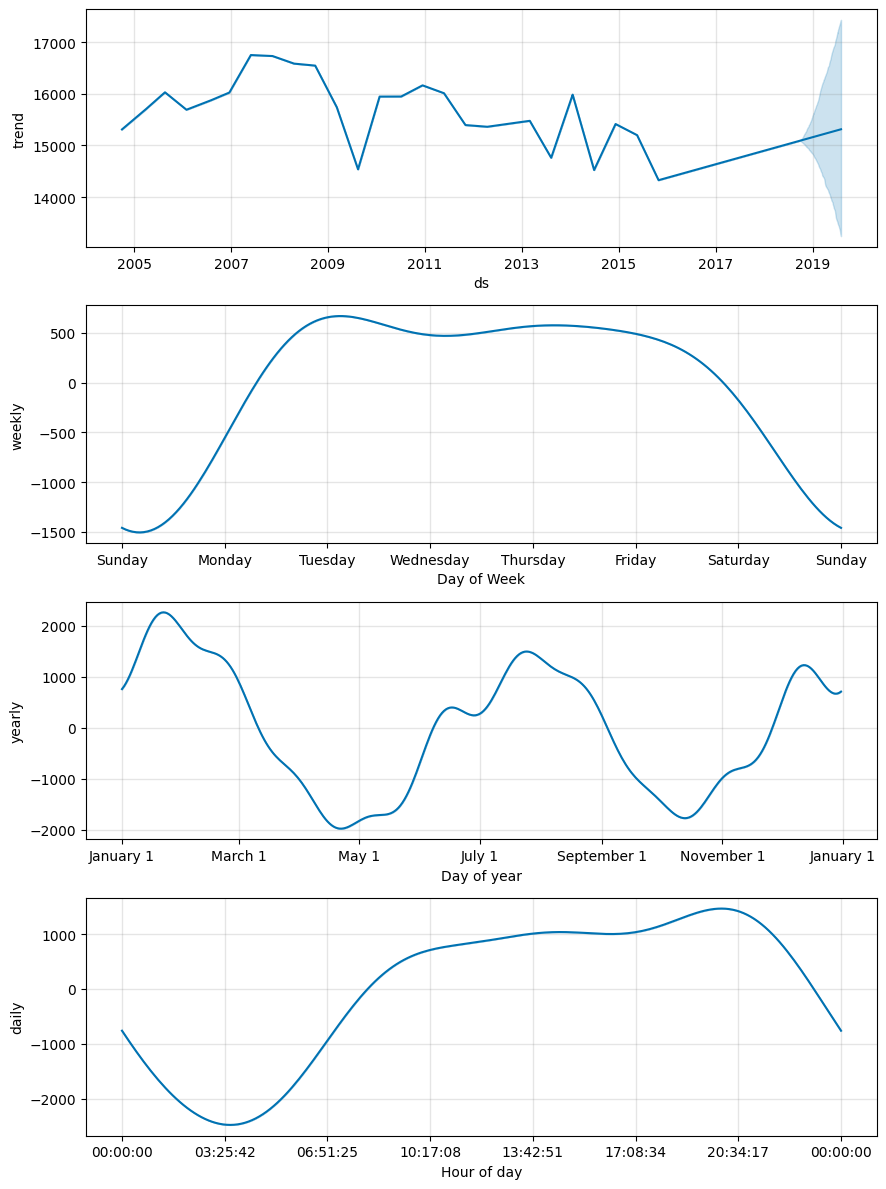

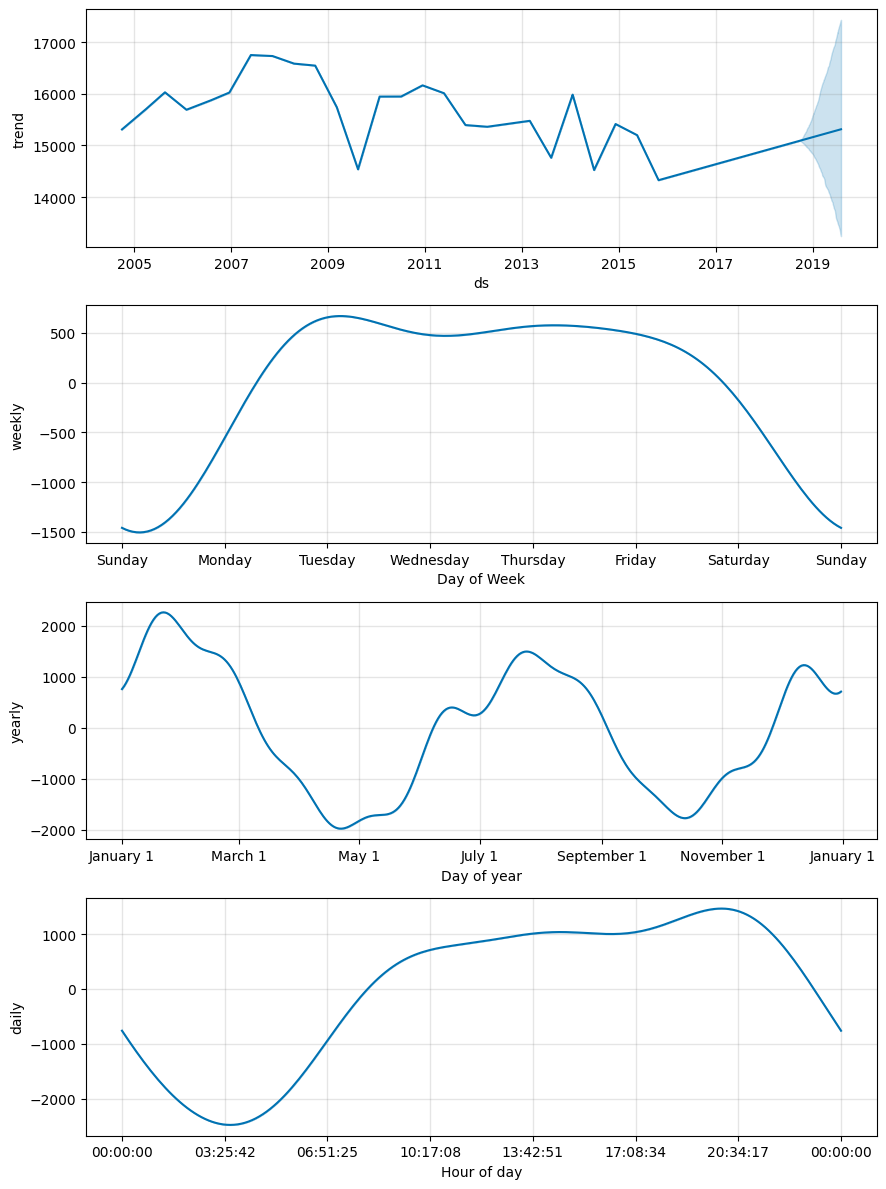

In [ ]:
#### Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [ ]:
#Time Series Analysis

1960-1962
#Cross Validation
1960-61 #Train dataset
1961-62 #Test dataset
1962-63 #Validation

1899

In [ ]:
df.head()

,ds,y
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [ ]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
df_cv.head()

INFO:prophet:Making 22 forecasts with cutoffs between 2007-03-29 00:00:00 and 2017-08-03 00:00:00


  0%|          | 0/22 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2007-03-29 01:00:00,13817.013516,12094.317823,15578.683278,13428.0,2007-03-29
1,2007-03-29 02:00:00,13199.837019,11455.282799,14974.719456,12954.0,2007-03-29
2,2007-03-29 03:00:00,12835.758713,11072.578784,14570.648539,12794.0,2007-03-29
3,2007-03-29 04:00:00,12785.051661,11013.415092,14558.295355,12642.0,2007-03-29
4,2007-03-29 05:00:00,13096.152808,11225.486118,14912.087658,12802.0,2007-03-29


In [ ]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days 13:00:00,2.783256e+06,1668.309468,1294.553639,0.085624,0.072235,0.085892,0.771439
1,36 days 14:00:00,2.781364e+06,1667.742155,1294.100617,0.085590,0.072187,0.085855,0.771531
2,36 days 15:00:00,2.779513e+06,1667.187135,1293.762426,0.085563,0.072187,0.085824,0.771635
3,36 days 16:00:00,2.777699e+06,1666.643030,1293.474795,0.085539,0.072170,0.085795,0.771779
4,36 days 17:00:00,2.775765e+06,1666.062599,1293.135947,0.085512,0.072158,0.085764,0.771911


https://docs.google.com/document/d/1kflJtIrV23DaGH2bF7fLJyTYq-uqsu2D7SFrRpdQ3bk/edit?usp=sharing

In [ ]:
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days 13:00:00,2.783256e+06,1668.309468,1294.553639,0.085624,0.072235,0.085892,0.771439
1,36 days 14:00:00,2.781364e+06,1667.742155,1294.100617,0.085590,0.072187,0.085855,0.771531
2,36 days 15:00:00,2.779513e+06,1667.187135,1293.762426,0.085563,0.072187,0.085824,0.771635
3,36 days 16:00:00,2.777699e+06,1666.643030,1293.474795,0.085539,0.072170,0.085795,0.771779
4,36 days 17:00:00,2.775765e+06,1666.062599,1293.135947,0.085512,0.072158,0.085764,0.771911


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


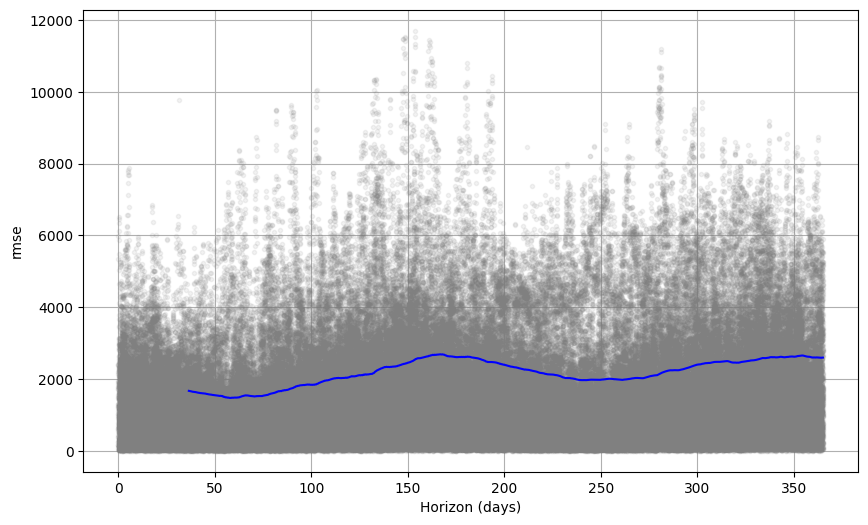

In [ ]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

FINAL OUTCOME OF THE NOTEBOOK

This notebook successfully:

✅ Loads AMERICA ENERGY CONSUMPTION time series data

✅ Cleans and prepares dataset

✅ Trains Prophet forecasting model

✅ Predicts future CONSUMPTION counts for 365 days

✅ Visualizes trend and seasonality

✅ Evaluates model accuracy using cross-validation and RMSE